# Allgemeine Grundlagen zur Wärmelehre

## Wärme und Thermodynamik
- Wärme ist eine Energieform.
- Thermodynamik beschreibt makroskopische Größen $T,\, p,\, V,\, U$.
- Statistische Physik leitet diese aus Mikromodellen ab.

## Hauptsätze der Wärmelehre
1. **0. Hauptsatz**  
   Wenn Systeme A und B mit C im thermischen Gleichgewicht stehen, dann stehen A und B miteinander im Gleichgewicht.  
   → Grundlage der Temperaturdefinition.

2. **1. Hauptsatz**  
   $$
   \Delta Q + \Delta W = \Delta U
   $$

3. **2. Hauptsatz**  
   Wärme fließt niemals spontan von niedrigerer zu höherer Temperatur.

4. **3. Hauptsatz**  
   Absoluter Nullpunkt kann nicht in endlich vielen Schritten erreicht werden.

## Wärmekapazität und spezifische Wärme
- Wärmekapazität:
  $$
  C = \frac{\Delta Q}{\Delta T}
  $$
- spezifische Wärmekapazität:
  $$
  c = \frac{C}{m}
  $$
- Energieaufnahme ohne Phasenübergang:
  $$
  \Delta Q = c\,m\,\Delta T
  $$
  Einheiten:  
  $C: \frac{J}{K}$, $c: \frac{J}{kg\cdot K}$

## Kalorimetrie
Kalorimeter misst Wärmemengen, hier: Dewar-Gefäß.


# Experiment 1 — Bestimmung der spezifischen Wärme von Wasser

## Ziel
Bestimmen der spezifischen Wärmekapazität $c_w$ durch Erhitzen mit konstanter elektrischer Leistung.

## Prinzip
Elektrische Leistung:
$$
P_\mathrm{el} = U\,I
$$

Gesamtwärmekapazität:
$$
C_{\mathrm{ges}} = C_k + C_w
$$

Linearer Temperaturanstieg:
$$
\Delta T = b\,\Delta t
$$

### Wichtige Gleichungen
1. Energiebilanz:
   $$
   P_{\mathrm{el}}\Delta t = C_{\mathrm{ges}}\,\Delta T
   $$

2. Steigung des Temperaturanstiegs:
   $$
   b = \frac{U I}{C_k + C_w}
   $$

3. Wärmekapazität des Wassers:
   $$
   C_w = \frac{U I}{b} - C_k
   $$

4. spezifische Wärme des Wassers:
   $$
   c_w = \frac{C_w}{m_w}
   $$

## Auswertung


=== PW10 – Auswertung Experiment 1 (Batch-Version) ===

CSV-Datei: test.csv

Erste Zeilen der Datei:
   time_s  temperature_C
0       0          22.01
1      30          22.08
2      60          22.42
3      90          22.61
4     120          22.91

Verfügbare Spalten:
  [0] time_s
  [1] temperature_C

Verwende Zeitspalte:        time_s
Verwende Temperaturspalte:  temperature_C


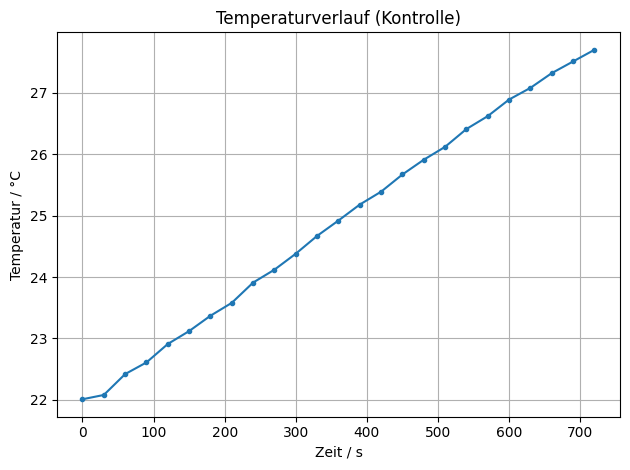


Fit-Bereich: t_min = 0.0 s, t_max = 720.0 s

=== Lineare Regression (T(t) im Heizbereich) ===
Steigung b = dT/dt = 0.008197 °C/s
Unsicherheit sigma_b ≈ 0.000050 °C/s
Achsenabschnitt a = 21.925 °C
Bestimmtheitsmaß R² = 0.99916

Verwendete sigma_T = 0.100 °C
Chi² = 6.639
Chi²/DoF (reduziertes Chi²) = 0.289 bei DoF = 23


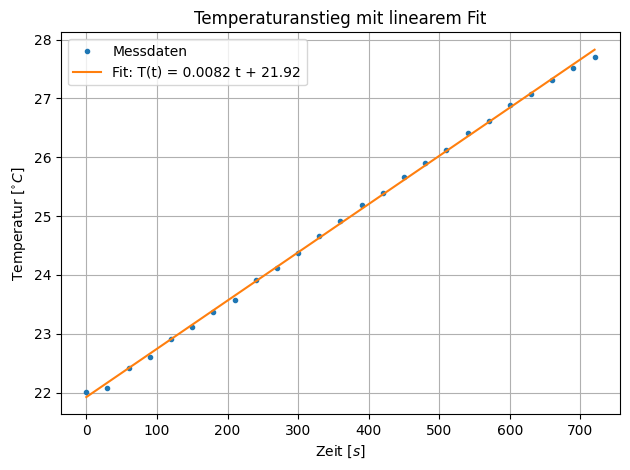


=== Eingestellte Messgrößen ===
U1 = 5.9000 V, U2 = 5.9500 V  ->  U_mean = 5.9250 V
I1 = 3.2000 A, I2 = 3.2500 A  ->  I_mean = 3.2250 A
Masse des Wassers m_w = 200.00 g = 0.2000 kg
Wärmekapazität des Kalorimeters C_k = 135.00 J/K

=== Thermische Ergebnisse ===
Elektrische Leistung P_el = U·I = 19.108 W
Wärmekapazität des Wassers C_w = 2195.99 J/K
Unsicherheit sigma_Cw ≈ 14.12 J/K

spezifische Wärmekapazität c_w = 10979.94 J/(kg·K)
Unsicherheit sigma_cw ≈ 70.62 J/(kg·K)

Literaturwert c_w,lit ≈ 4190 J/(kg·K)
relative Abweichung ≈ 162.05 %


In [9]:
#!/usr/bin/env python3
"""
PW10 – Auswertung Experiment 1 (spezifische Wärme von Wasser)
Nicht-interaktive Version: alle Parameter werden im Konfigurationsblock gesetzt.

Benötigt:
- numpy
- pandas
- matplotlib
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt

# ============================================================
#                 KONFIGURATION HIER ANPASSEN
# ============================================================

# Pfad zur CSV-Datei
CSV_PATH = "test.csv"

# Spalten für Zeit und Temperatur
# Entweder Name der Spalte (String) ODER Index (int, 0-basiert)
TIME_COL = "time_s"          # z.B. "time_s" oder 0
TEMP_COL = "temperature_C"   # z.B. "temperature_C" oder 1

# Fitbereich in Sekunden (nur dieser Bereich wird linear gefittet)
T_FIT_MIN = 0.0      # in s
T_FIT_MAX = 720.0    # in s

# Typische Unsicherheit der Temperaturmessung (für Chi²)
SIGMA_T = 0.1        # in °C

# Elektrische Messgrößen (Anfang/Ende), werden gemittelt
U1 = 5.90   # V, z.B. Anfang
U2 = 5.95   # V, z.B. Ende
I1 = 3.20   # A, z.B. Anfang
I2 = 3.25   # A, z.B. Ende

# Masse des Wassers
M_W_G = 200.0        # in g
# Wärmekapazität des Kalorimeters
C_K = 135.0          # in J/K

# ============================================================
#                AB HIER NICHTS MEHR ÄNDERN
# ============================================================

print("=== PW10 – Auswertung Experiment 1 (Batch-Version) ===\n")
print(f"CSV-Datei: {CSV_PATH}")

# ----------------- CSV einlesen ----------------- #

try:
    df = pd.read_csv(CSV_PATH, engine="python")
except Exception as e:
    print("Fehler beim Einlesen mit Standard-Einstellungen:", e)
    print("Versuche es mit 'sep=; decimal=,'.")
    df = pd.read_csv(CSV_PATH, sep=";", decimal=",", engine="python")

print("\nErste Zeilen der Datei:")
print(df.head())
print("\nVerfügbare Spalten:")
for i, col in enumerate(df.columns):
    print(f"  [{i}] {col}")

# Hilfsfunktion, um Spaltennamen aus Konfiguration zu interpretieren
def get_column(col_spec, df):
    if isinstance(col_spec, int):
        return df.columns[col_spec]
    else:
        return col_spec

time_col = get_column(TIME_COL, df)
temp_col = get_column(TEMP_COL, df)

print(f"\nVerwende Zeitspalte:        {time_col}")
print(f"Verwende Temperaturspalte:  {temp_col}")

t = df[time_col].values  # Zeit in s
T = df[temp_col].values  # Temperatur in °C

# ----------------- Plot zur Kontrolle ----------------- #

plt.figure()
plt.plot(t, T, marker=".", linestyle="-")
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Temperaturverlauf (Kontrolle)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------- Fit-Bereich auswählen ----------------- #

print(f"\nFit-Bereich: t_min = {T_FIT_MIN} s, t_max = {T_FIT_MAX} s")
mask = (t >= T_FIT_MIN) & (t <= T_FIT_MAX)
t_fit = t[mask]
T_fit = T[mask]

if len(t_fit) < 2:
    raise RuntimeError("Zu wenige Punkte im Fit-Bereich! Fit-Bereich prüfen.")

# ----------------- Lineare Regression ----------------- #
# T(t) = b * t + a

params, cov = np.polyfit(t_fit, T_fit, deg=1, cov=True)
b, a = params
sigma_b = sqrt(cov[0, 0])

# Modellwerte und Residuen
T_fit_model = b * t_fit + a
residuals = T_fit - T_fit_model

# Bestimmtheitsmaß R^2
SS_res = np.sum(residuals**2)
SS_tot = np.sum((T_fit - np.mean(T_fit))**2)
R2 = 1.0 - SS_res / SS_tot

print("\n=== Lineare Regression (T(t) im Heizbereich) ===")
print(f"Steigung b = dT/dt = {b:.6f} °C/s")
print(f"Unsicherheit sigma_b ≈ {sigma_b:.6f} °C/s")
print(f"Achsenabschnitt a = {a:.3f} °C")
print(f"Bestimmtheitsmaß R² = {R2:.5f}")

# Chi² und reduziertes Chi²
N = len(T_fit)
dof = N - 2  # 2 Fitparameter: a und b

chi2 = np.sum((residuals / SIGMA_T)**2)
chi2_red = chi2 / dof

print(f"\nVerwendete sigma_T = {SIGMA_T:.3f} °C")
print(f"Chi² = {chi2:.3f}")
print(f"Chi²/DoF (reduziertes Chi²) = {chi2_red:.3f} bei DoF = {dof}")

# Fit-Gerade zum Plotten
t_plot = np.linspace(T_FIT_MIN, T_FIT_MAX, 200)
T_plot = b * t_plot + a

plt.figure()
plt.plot(t, T, ".", label="Messdaten")
plt.plot(t_plot, T_plot, "-", label=f"Fit: T(t) = {b:.4f} t + {a:.2f}")
plt.xlabel(r"Zeit $[s]$")
plt.ylabel(r"Temperatur $[^{\circ}C]$")
plt.title("Temperaturanstieg mit linearem Fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------- Auswertung: U, I, m_w, C_w, c_w ----------------- #

U_mean = 0.5 * (U1 + U2)
I_mean = 0.5 * (I1 + I2)

print("\n=== Eingestellte Messgrößen ===")
print(f"U1 = {U1:.4f} V, U2 = {U2:.4f} V  ->  U_mean = {U_mean:.4f} V")
print(f"I1 = {I1:.4f} A, I2 = {I2:.4f} A  ->  I_mean = {I_mean:.4f} A")

m_w = M_W_G / 1000.0
print(f"Masse des Wassers m_w = {M_W_G:.2f} g = {m_w:.4f} kg")
print(f"Wärmekapazität des Kalorimeters C_k = {C_K:.2f} J/K")

P_el = U_mean * I_mean  # W = J/s

# C_w = U I / b - C_k
C_w = P_el / b - C_K

# Unsicherheit in C_w nur aus b (grobe Abschätzung)
sigma_Cw = abs(-P_el / (b**2)) * sigma_b

# spezifische Wärme
c_w = C_w / m_w
sigma_cw = sigma_Cw / m_w

print("\n=== Thermische Ergebnisse ===")
print(f"Elektrische Leistung P_el = U·I = {P_el:.3f} W")
print(f"Wärmekapazität des Wassers C_w = {C_w:.2f} J/K")
print(f"Unsicherheit sigma_Cw ≈ {sigma_Cw:.2f} J/K")

print(f"\nspezifische Wärmekapazität c_w = {c_w:.2f} J/(kg·K)")
print(f"Unsicherheit sigma_cw ≈ {sigma_cw:.2f} J/(kg·K)")

# Vergleich mit Literaturwert
c_lit = 4.19e3  # J/(kg K)
abweichung_rel = (c_w - c_lit) / c_lit * 100.0

print(f"\nLiteraturwert c_w,lit ≈ {c_lit:.0f} J/(kg·K)")
print(f"relative Abweichung ≈ {abweichung_rel:.2f} %")



# Experiment 2 — Bestimmung der Schmelzwärme von Eis

## Begriffe
- Latente Wärme: Aufnahme/Abgabe ohne Temperaturänderung.
- spezifische Schmelzwärme:
  $$
  S = \frac{Q_s}{m}
  $$

## Mischungsmethode
Heißes Wasser der Masse $m_w$ und Temperatur $T_1$ wird mit Eis der Masse $m_e$ bei $T_S = 0^\circ\mathrm{C}$ gemischt.
Kalorimeter mit Wärmekapazität $C_k$ wird berücksichtigt.

### Energiebilanzen

**Abgegebene Wärme des Wassers + Kalorimeter:**
$$
\Delta Q_1 = ( C_k + m_w c_w)(T_1 - T_m)
$$

**Aufgenommene Wärme des Eises:**
$$
\Delta Q_2 = m_e S + m_e c_w (T_m - T_S)
$$

**Energieerhaltung:**
$$
(C_k + m_w c_w)(T_1 - T_m)
=
m_e S + m_e c_w (T_m - T_S)
$$

Auflösen nach $ S $:

$$
S = \frac{(C_k + m_w c_w)(T_1 - T_m) - m_e c_w (T_m - T_S)}{m_e}
$$




=== PW10 – Auswertung Experiment 2 (Batch-Version) ===

CSV-Datei: test2.csv

Erste Zeilen der Datei:
   time_s  temperature_C
0       0          69.85
1       2          69.82
2       4          69.78
3       6          69.75
4       8          69.72

Verfügbare Spalten:
  [0] time_s
  [1] temperature_C

Verwende Zeitspalte:        time_s
Verwende Temperaturspalte:  temperature_C


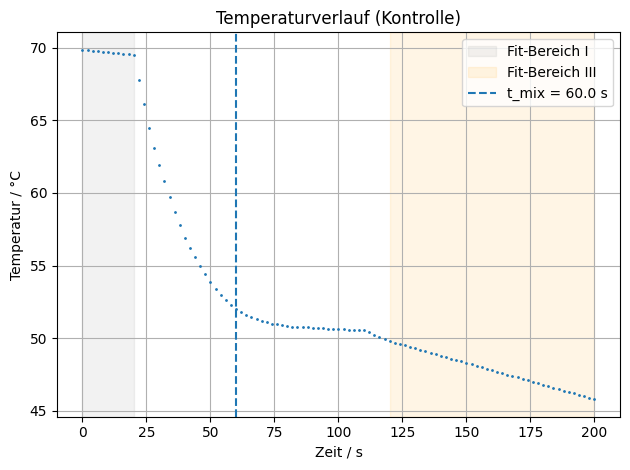


Fit-Bereich I (vor Mischen):  t ∈ [0.0, 20.0] s
Fit-Bereich III (nach Mischen): t ∈ [120.0, 200.0] s
t_mix = 60.0 s

=== Fit Bereich I (vor Mischen) ===
T(t) = b1 * t + a1
b1 = -0.017545 °C/s,  sigma_b1 ≈ 0.000169 °C/s
a1 = 69.854 °C,    sigma_a1 ≈ 0.002 °C
R² (Bereich I) = 0.99917
Chi² = 0.011,  Chi²/DoF = 0.001 bei DoF = 9

=== Fit Bereich III (nach Mischen) ===
T(t) = b3 * t + a3
b3 = -0.050000 °C/s,  sigma_b3 ≈ 0.000000 °C/s
a3 = 55.800 °C,    sigma_a3 ≈ 0.000 °C
R² (Bereich III) = 1.00000
Chi² = 0.000,  Chi²/DoF = 0.000 bei DoF = 39

=== Extrapolation auf t_mix ===
T1(t_mix) ≈ 68.801 °C   (vor Mischen)
Tm(t_mix) ≈ 52.800 °C   (Mischung)
sigma_T1 ≈ 0.009 °C
sigma_Tm ≈ 0.000 °C


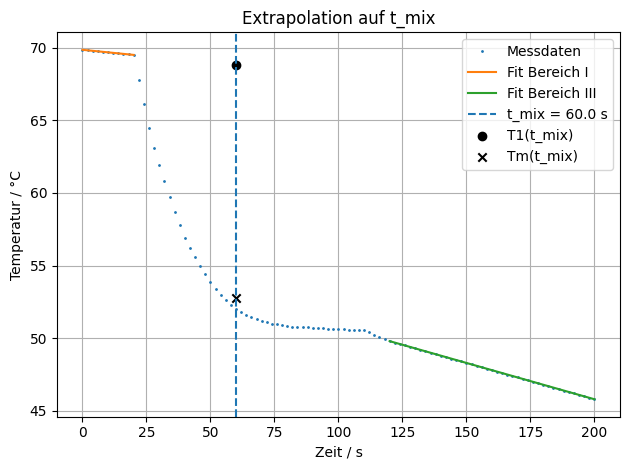


=== Eingestellte thermische Größen ===
m_w = 200.00 g = 0.2000 kg
m_e = 30.00 g = 0.0300 kg
C_k = 100.00 J/K
c_w = 4190.0 J/(kg·K)
T_S = 0.00 °C

=== Ergebnis: spezifische Schmelzwärme von Eis ===
S = 279063 J/kg
sigma_S ≈ 266 J/kg

Literaturwert S_lit ≈ 334000 J/kg
relative Abweichung ≈ -16.45 %

Fertig. Alle Werte wurden mit den oben gesetzten Parametern berechnet.


In [ ]:

# ============================================================
#                 KONFIGURATION HIER ANPASSEN
# ============================================================

# Pfad zur CSV-Datei (Temperatur-Zeit-Daten mit hoher Abtastrate)
CSV_PATH = "test2.csv"

# Spalten für Zeit und Temperatur
# Entweder Name der Spalte (String) ODER Index (int, 0-basiert)
TIME_COL = "time_s"          # z.B. "time_s" oder 0
TEMP_COL = "temperature_C"   # z.B. "temperature_C" oder 1

# Bereiche für lineare Fits
# Bereich (I): VOR Einbringen des Eises (nur warmes Wasser)
PRE_MIN = 0.0      # in s
PRE_MAX = 20.0     # in s

# Bereich (III): NACH vollständigem Schmelzen (nur Mischung)
POST_MIN = 120.0   # in s
POST_MAX = 200.0   # in s

# Position der "virtuellen" Mischzeit (vertikale Linie AB in Abb. 3)
T_MIX = 60.0       # in s  (ungefähr mitten im Mischbereich)

# Typische Unsicherheit der Temperaturmessung (für Chi²)
SIGMA_T = 0.1      # in °C

# Thermische Größen
# Masse des anfänglichen Wassers (ohne Eis!)
M_W_G = 200.0      # in g

# Masse des Eises
M_E_G = 30.0       # in g

# Wärmekapazität des Kalorimeters (aus Anleitung Exp. 2)
C_K = 100.0        # in J/K

# spezifische Wärmekapazität von Wasser
C_W = 4.19e3       # in J/(kg·K)

# Schmelztemperatur von Eis
T_S = 0.0          # in °C

# ============================================================
#                AB HIER NICHTS MEHR ÄNDERN
# ============================================================

print("=== PW10 – Auswertung Experiment 2 (Batch-Version) ===\n")
print(f"CSV-Datei: {CSV_PATH}")

# ----------------- CSV einlesen ----------------- #

try:
    df = pd.read_csv(CSV_PATH, engine="python")
except Exception as e:
    print("Fehler beim Einlesen mit Standard-Einstellungen:", e)
    print("Versuche es mit 'sep=; decimal=,'.")
    df = pd.read_csv(CSV_PATH, sep=";", decimal=",", engine="python")

print("\nErste Zeilen der Datei:")
print(df.head())
print("\nVerfügbare Spalten:")
for i, col in enumerate(df.columns):
    print(f"  [{i}] {col}")

def get_column(col_spec, df):
    if isinstance(col_spec, int):
        return df.columns[col_spec]
    else:
        return col_spec

time_col = get_column(TIME_COL, df)
temp_col = get_column(TEMP_COL, df)

print(f"\nVerwende Zeitspalte:        {time_col}")
print(f"Verwende Temperaturspalte:  {temp_col}")

t = df[time_col].values
T = df[temp_col].values

# ----------------- Gesamtplot ----------------- #

plt.figure()
plt.plot(t, T, ".", markersize=2)
plt.axvspan(PRE_MIN, PRE_MAX, alpha=0.1, color="grey", label="Fit-Bereich I")
plt.axvspan(POST_MIN, POST_MAX, alpha=0.1, color="orange", label="Fit-Bereich III")
plt.axvline(T_MIX, linestyle="--", label=f"t_mix = {T_MIX} s")
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Temperaturverlauf (Kontrolle)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------- Fit-Bereiche auswählen ----------------- #

print(f"\nFit-Bereich I (vor Mischen):  t ∈ [{PRE_MIN}, {PRE_MAX}] s")
print(f"Fit-Bereich III (nach Mischen): t ∈ [{POST_MIN}, {POST_MAX}] s")
print(f"t_mix = {T_MIX} s")

mask_pre = (t >= PRE_MIN) & (t <= PRE_MAX)
mask_post = (t >= POST_MIN) & (t <= POST_MAX)

t_pre = t[mask_pre]
T_pre = T[mask_pre]

t_post = t[mask_post]
T_post = T[mask_post]

if len(t_pre) < 2 or len(t_post) < 2:
    raise RuntimeError("Zu wenige Punkte in einem der Fit-Bereiche! Bereiche prüfen.")

# ----------------- Lineare Regression: Bereich I ----------------- #
# T_pre(t) = b1 * t + a1

params1, cov1 = np.polyfit(t_pre, T_pre, deg=1, cov=True)
b1, a1 = params1
sigma_b1 = sqrt(cov1[0, 0])
sigma_a1 = sqrt(cov1[1, 1])

T_pre_model = b1 * t_pre + a1
res_pre = T_pre - T_pre_model

SS_res_pre = np.sum(res_pre**2)
SS_tot_pre = np.sum((T_pre - np.mean(T_pre))**2)
R2_pre = 1.0 - SS_res_pre / SS_tot_pre

N_pre = len(T_pre)
dof_pre = N_pre - 2
chi2_pre = np.sum((res_pre / SIGMA_T)**2)
chi2_red_pre = chi2_pre / dof_pre

print("\n=== Fit Bereich I (vor Mischen) ===")
print(f"T(t) = b1 * t + a1")
print(f"b1 = {b1:.6f} °C/s,  sigma_b1 ≈ {sigma_b1:.6f} °C/s")
print(f"a1 = {a1:.3f} °C,    sigma_a1 ≈ {sigma_a1:.3f} °C")
print(f"R² (Bereich I) = {R2_pre:.5f}")
print(f"Chi² = {chi2_pre:.3f},  Chi²/DoF = {chi2_red_pre:.3f} bei DoF = {dof_pre}")

# ----------------- Lineare Regression: Bereich III ----------------- #
# T_post(t) = b3 * t + a3

params3, cov3 = np.polyfit(t_post, T_post, deg=1, cov=True)
b3, a3 = params3
sigma_b3 = sqrt(cov3[0, 0])
sigma_a3 = sqrt(cov3[1, 1])

T_post_model = b3 * t_post + a3
res_post = T_post - T_post_model

SS_res_post = np.sum(res_post**2)
SS_tot_post = np.sum((T_post - np.mean(T_post))**2)
R2_post = 1.0 - SS_res_post / SS_tot_post

N_post = len(T_post)
dof_post = N_post - 2
chi2_post = np.sum((res_post / SIGMA_T)**2)
chi2_red_post = chi2_post / dof_post

print("\n=== Fit Bereich III (nach Mischen) ===")
print(f"T(t) = b3 * t + a3")
print(f"b3 = {b3:.6f} °C/s,  sigma_b3 ≈ {sigma_b3:.6f} °C/s")
print(f"a3 = {a3:.3f} °C,    sigma_a3 ≈ {sigma_a3:.3f} °C")
print(f"R² (Bereich III) = {R2_post:.5f}")
print(f"Chi² = {chi2_post:.3f},  Chi²/DoF = {chi2_red_post:.3f} bei DoF = {dof_post}")

# ----------------- Extrapolation auf t_mix ----------------- #

# T1 = Temperatur des Wassers (und Kalorimeters) vor Mischen, extrapoliert
T1 = b1 * T_MIX + a1
# Tm = Mischungstemperatur, extrapoliert aus Bereich III
Tm = b3 * T_MIX + a3

# Unsicherheit auf T1 und Tm aus Fit-Kovarianzen
# Var(T) = Var(a) + t^2 Var(b) + 2 t Cov(a,b)
var_T1 = cov1[1, 1] + (T_MIX**2) * cov1[0, 0] + 2 * T_MIX * cov1[0, 1]
var_Tm = cov3[1, 1] + (T_MIX**2) * cov3[0, 0] + 2 * T_MIX * cov3[0, 1]
sigma_T1 = sqrt(abs(var_T1))
sigma_Tm = sqrt(abs(var_Tm))

print("\n=== Extrapolation auf t_mix ===")
print(f"T1(t_mix) ≈ {T1:.3f} °C   (vor Mischen)")
print(f"Tm(t_mix) ≈ {Tm:.3f} °C   (Mischung)")
print(f"sigma_T1 ≈ {sigma_T1:.3f} °C")
print(f"sigma_Tm ≈ {sigma_Tm:.3f} °C")

# Plot mit Fit-Gerade und t_mix
t_plot_pre = np.linspace(PRE_MIN, PRE_MAX, 200)
T_plot_pre = b1 * t_plot_pre + a1
t_plot_post = np.linspace(POST_MIN, POST_MAX, 200)
T_plot_post = b3 * t_plot_post + a3

plt.figure()
plt.plot(t, T, ".", markersize=2, label="Messdaten")
plt.plot(t_plot_pre, T_plot_pre, "-", label="Fit Bereich I")
plt.plot(t_plot_post, T_plot_post, "-", label="Fit Bereich III")
plt.axvline(T_MIX, linestyle="--", label=f"t_mix = {T_MIX} s")
plt.scatter([T_MIX], [T1], marker="o", color="k", label="T1(t_mix)")
plt.scatter([T_MIX], [Tm], marker="x", color="k", label="Tm(t_mix)")
plt.xlabel("Zeit / s")
plt.ylabel("Temperatur / °C")
plt.title("Extrapolation auf t_mix")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------- Berechnung der Schmelzwärme S ----------------- #

m_w = M_W_G / 1000.0   # kg
m_e = M_E_G / 1000.0   # kg

print("\n=== Eingestellte thermische Größen ===")
print(f"m_w = {M_W_G:.2f} g = {m_w:.4f} kg")
print(f"m_e = {M_E_G:.2f} g = {m_e:.4f} kg")
print(f"C_k = {C_K:.2f} J/K")
print(f"c_w = {C_W:.1f} J/(kg·K)")
print(f"T_S = {T_S:.2f} °C")

# Abkürzungen
A = C_K + m_w * C_W    # J/K
B = m_e * C_W          # J/K

# Energiebilanz:
# (C_k + m_w c_w)(T1 - Tm) = m_e S + m_e c_w (Tm - T_S)
# -> S = [ A(T1 - Tm) - B(Tm - T_S) ] / m_e

num = A * (T1 - Tm) - B * (Tm - T_S)
S = num / m_e   # J/kg

# Unsicherheit von S aus T1 und Tm (vereinfachte Fehlerfortpflanzung)
# S = N / m_e,  N = A T1 - (A + B) Tm + B T_S
# dS/dT1 = A / m_e
# dS/dTm = -(A + B) / m_e
dSdT1 = A / m_e
dSdTm = -(A + B) / m_e

sigma_S = sqrt((dSdT1**2) * (sigma_T1**2) + (dSdTm**2) * (sigma_Tm**2))

print("\n=== Ergebnis: spezifische Schmelzwärme von Eis ===")
print(f"S = {S:.0f} J/kg")
print(f"sigma_S ≈ {sigma_S:.0f} J/kg")

# Vergleich mit Literaturwert ~ 3.34e5 J/kg
S_lit = 3.34e5
abweichung_rel = (S - S_lit) / S_lit * 100.0

print(f"\nLiteraturwert S_lit ≈ {S_lit:.0f} J/kg")
print(f"relative Abweichung ≈ {abweichung_rel:.2f} %")